# Taller: Análisis de Sentimientos en Tweets en Español (TASS 2018)

En este notebook vamos a construir paso a paso un clasificador de sentimiento para tweets en español utilizando el corpus de **TASS 2018**.  
El objetivo pedagógico es entender cada etapa típica de un *pipeline* de NLP aplicado a clasificación de texto:

1. Contexto del problema y del corpus TASS.
2. Configuración del entorno de trabajo.
3. Carga y exploración de los datos.
4. Preprocesamiento de texto en español.
5. Representación mediante **Bolsa de Palabras (Bag of Words)**.
6. Manejo del desbalance de clases.
7. Definición y entrenamiento de un modelo **Softmax (Regresión Logística Multinomial)**.
8. Evaluación con métricas de clasificación y matriz de confusión.

Cada bloque de código irá precedido de una breve explicación en español para que el flujo completo sea fácil de seguir en el taller.


## 1. Configuración del entorno

En este bloque definimos la ruta donde se encuentran los datos de TASS y añadimos el directorio actual al `sys.path` para poder importar módulos locales (por ejemplo, la clase `TextProcessing` que usaremos para el preprocesamiento).


In [ ]:
import os
import sys
PATH = os.getcwd()
DIR_DATA = PATH + '{0}data{0}tass{0}'.format(os.sep)
sys.path.append(PATH) if PATH not in list(sys.path) else None
DIR_DATA

'/content/courseNLP/examples/data/tass/'

## 2. Contexto: TASS 2018

**TASS** es una campaña de evaluación y taller científico centrado en el **análisis de sentimientos en Twitter en español**.  
En la edición 2018, una de las tareas principales consiste en predecir la **polaridad global** de cada tweet (por ejemplo, positiva, negativa, neutra, etc.) a partir de texto corto, ruidoso y con variantes dialectales.

En este taller utilizaremos una versión de ese corpus para entrenar un modelo supervisado de clasificación de sentimiento.

Más información: <http://tass.sepln.org/2018/>


## 3. Importación de librerías

En el siguiente bloque importamos las librerías necesarias para:

- Manipular datos (`pandas`, `numpy`).
- Visualizar resultados (`matplotlib`, `seaborn`).
- Preprocesar y transformar texto (`TextProcessing`, `CountVectorizer`).
- Construir y evaluar modelos (`LogisticRegression`, métricas de `sklearn`).
- Tratar el desbalance de clases (`RandomOverSampler`).

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
#from logic.text_processing import TextProcessing
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, ShuffleSplit
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix, recall_score, log_loss
from sklearn.metrics import f1_score, accuracy_score, precision_score

## clas epara procesamiento de texto

In [ ]:
!pip install emoji

In [ ]:
import re
import nltk
import spacy
import unicodedata
from nltk import TweetTokenizer
from spacy.lang.es import Spanish
from spacy.lang.en import English
from nltk.util import ngrams
import emoji


class TextProcessing(object):
    name = 'Text Processing'
    lang = 'es'

    def __init__(self, lang: str = 'es'):
        self.lang = lang
        self.nlp = TextProcessing.load_spacy(lang=lang)

    @staticmethod
    def load_spacy(lang: str):
        result = None
        try:
            if lang == 'es':
                result = spacy.load('es_core_news_sm')
            else:
                result = spacy.load('en_core_web_sm')
            print('Language: {0}\n{1}: {2}'.format(TextProcessing.name, lang, result.pipe_names))
        except Exception as e:
            print('Error load_sapcy: {0}'.format(e))
        return result

    def analysis_pipe(self, text: str):
        doc = None
        try:
            doc = self.nlp(text=text)
        except Exception as e:
            print('Error analysis_pipe: {0}'.format(e))
        return doc

    @staticmethod
    def proper_encoding(text: str):
        result = ''
        try:
            text = unicodedata.normalize('NFD', text)
            text = text.encode('ascii', 'ignore')
            result = text.decode("utf-8")
        except Exception as e:
            print('Error proper_encoding: {0}'.format(e))
        return result

    @staticmethod
    def stopwords(text: str):
        result = ''
        try:
            nlp = Spanish()if TextProcessing == 'es' else English()
            doc = nlp(text)
            token_list = [token.text for token in doc]
            sentence = []
            for word in token_list:
                lexeme = nlp.vocab[word]
                if not lexeme.is_stop:
                    sentence.append(word)
            result = ' '.join(sentence)
        except Exception as e:
            print('Error stopwords: {0}'.format(e))
        return result

    @staticmethod
    def remove_patterns(text: str):
        result = ''
        try:
            text = re.sub(r'\©|\×|\⇔|\_|\»|\«|\~|\#|\$|\€|\Â|\�|\¬', '', text)
            text = re.sub(r'\,|\;|\:|\!|\¡|\’|\‘|\”|\“|\"|\'|\`', '', text)
            text = re.sub(r'\}|\{|\[|\]|\(|\)|\<|\>|\?|\¿|\°|\|', '', text)
            text = re.sub(r'\/|\-|\+|\*|\=|\^|\%|\&|\$', '', text)
            text = re.sub(r'\b\d+(?:\.\d+)?\s+', '', text)
            result = text.lower()
        except Exception as e:
            print('Error remove_patterns: {0}'.format(e))
        return result
    @staticmethod
    def segment_hashtag(text):
        """
        Transforma #OdioMiTrabajo -> odio mi trabajo
        """
        # 1. Quitar el símbolo #
        content = text.replace('#', '')

        # 2. Separar por mayúsculas (CamelCase)
        # Ejemplo: "QueMal" -> "Que Mal"
        content = re.sub(r'([a-z])([A-Z])', r'\1 \2', content)

        # 3. Separar números de letras
        # Ejemplo: "Tass2018" -> "Tass 2018"
        content = re.sub(r'([a-zA-Z])(\d)', r'\1 \2', content)
        content = re.sub(r'(\d)([a-zA-Z])', r'\1 \2', content)

        return content.lower()

    """ @staticmethod """
    def transformer(self, text: str, stopwords: bool = False, lemmatize: bool = True, decode_emoji: bool = True):
        result = ''
        try:
            # 1. TRADUCIR EMOJIS (DEBE SER LO PRIMERO)
            if decode_emoji:
                # Convierte 😂 -> :cara_llorando_de_risa:
                text = emoji.demojize(text, language='es')
                # Quitamos los ":" y cambiamos "_" por espacio para que sean palabras normales
                # ":cara_sonriente:" -> "cara sonriente"
                text = text.replace(':', ' ').replace('_', ' ')

            # --- PROCESAMIENTO ESPECIAL DE HASHTAGS ---
            # En lugar de borrarlos, buscamos todos los #palabras y los segmentamos
            hashtags = re.findall(r'#(\w+)', text)
            for ht in hashtags:
                segmented = self.segment_hashtag(ht)
                # Reemplazamos el #Hashtag original por su versión segmentada
                text = text.replace(f'#{ht}', segmented)

            # 2. LIMPIEZA BÁSICA
            text_out = TextProcessing.proper_encoding(text)
            text_out = text_out.lower()

            # Limpieza de URLs, Menciones y Hashtags
            text_out = re.sub(r'(?i)\b((?:https?://|www\d{0,3}[.]|[a-z0-9.\-]+[.][a-z]{2,4}/)(?:[^\s()<>]+|\(([^\s()<>]+'
                              r'|(\([^\s()<>]+\)))*\))+(?:\(([^\s()<>]+|(\([^\s()<>]+\)))*\)|[^\s`!()\[\]{};:\'".,<>?«»“”‘’]))',
                              '[URL]', text_out)
            text_out = re.sub("@([A-Za-z0-9_]{1,40})", '[MENTION]', text_out)
            text_out = re.sub("#([A-Za-z0-9_]{1,40})", '[HASTAG]', text_out)

            text_out = TextProcessing.remove_patterns(text_out)

            # 3. STOPWORDS
            if stopwords:
                text_out = self.stopwords(text_out)

            # 4. LEMATIZACIÓN (Esto agrupa "llorando", "llorar", "llore")
            if lemmatize and self.nlp:
                doc = self.nlp(text_out)
                text_out = " ".join([token.lemma_ for token in doc])

            text_out = re.sub(r'\s+', ' ', text_out).strip()
            result = text_out if text_out != '' else None

        except Exception as e:
            print('Error transformer: {0}'.format(e))
        return result

    @staticmethod
    def tokenizer(text: str):
        val = []
        try:
            text_tokenizer = TweetTokenizer()
            val = text_tokenizer.tokenize(text)
        except Exception as e:
            print('Error make_ngrams: {0}'.format(e))
        return val

    @staticmethod
    def make_ngrams(text: str, num: int):
        result = ''
        try:
            n_grams = ngrams(nltk.word_tokenize(text), num)
            result = [' '.join(grams) for grams in n_grams]
        except Exception as e:
            print('Error make_ngrams: {0}'.format(e))
        return result

    @staticmethod
    def tagger(text: str):
        result = None
        try:
            list_tagger = []
            doc = TextProcessing.analysis_pipe(text=text)
            for token in doc:
                item = {'text': token.text, 'lemma': token.lemma_, 'stem': token._.stem, 'pos': token.pos_,
                        'tag': token.tag_, 'dep': token.dep_, 'shape': token.shape_, 'is_alpha': token.is_alpha,
                        'is_stop': token.is_stop, 'is_digit': token.is_digit, 'is_punct': token.is_punct}
                list_tagger.append(item)
            result = list_tagger
        except Exception as e:
            print('Error tagger: {0}'.format(e))
        return result

## 4. Inicialización de utilidades de preprocesamiento

Instanciamos:

- `TextProcessing()`: encapsula las transformaciones de texto (limpieza, normalización, etc.).
- `LabelEncoder()`: utilidad para mapear etiquetas de texto a códigos numéricos si fuera necesario.

Esto nos permite mantener el preprocesamiento separado de la lógica del modelo.


In [ ]:
import spacy

try:
    spacy.load('es_core_news_sm')
except OSError:
    print('Downloading spaCy model es_core_news_sm...')
    !python -m spacy download es_core_news_sm
    print('Model downloaded successfully.')
    # Try loading again after download
    spacy.load('es_core_news_sm')

In [ ]:
tp = TextProcessing()
le = LabelEncoder()

Language: Text Processing
es: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


Una vez que el modelo se haya descargado, puedes ejecutar la celda `tp = TextProcessing()` de nuevo. Esto debería inicializar `TextProcessing` correctamente.

## 5. Carga de los conjuntos de entrenamiento y prueba

A continuación cargamos:

- **`tass2018_es_train.csv`**: tweets etiquetados con su polaridad (conjunto de entrenamiento).
- **`tass2018_es_test.csv`**: tweets separados para evaluación final.

Es importante que durante el taller se explique el formato de las columnas (por ejemplo: identificador, contenido del tweet, etiqueta de polaridad).

In [ ]:
data_train = pd.read_csv(DIR_DATA + 'tass2018_es_train.csv', sep=',')
data_train[:5]

,tweetid,user,content,date,lang,sentiment/polarity/value
0,768213876278165504,OnceBukowski,-Me caes muy bien \n-Tienes que jugar más part...,2016-08-23 22:30:35,es,NONE
1,768213567418036224,anahorxn,@myendlesshazza a. que puto mal escribo\n\nb. ...,2016-08-23 22:29:21,es,N
2,768212591105703936,martitarey13,@estherct209 jajajaja la tuya y la d mucha gen...,2016-08-23 22:25:29,es,N
3,768221670255493120,endlessmilerr,Quiero mogollón a @AlbaBenito99 pero sobretodo...,2016-08-23 23:01:33,es,P
4,768221021300264964,JunoWTFL,Vale he visto la tia bebiendose su regla y me ...,2016-08-23 22:58:58,es,N


In [ ]:
data_test = pd.read_csv(DIR_DATA + 'tass2018_es_test.csv', sep=',')
data_test[:5]

,tweetid,user,content,date,lang,sentiment/polarity/value
0,770976639173951488,noseashetero,@noseashetero 1000/10 de verdad a ti que voy a...,2016-08-31 13:28:49,es,P
1,771092421866389508,Templelx,@piscolabisaereo @HistoriaNG @SPosteguillo las...,2016-08-31 21:08:54,es,P
2,771092111429083136,esskuu94,"Al final han sido 3h Bueno, mañana tengo fies...",2016-08-31 21:07:40,es,P
3,771092070572449796,__ariadna9,@Jorge_Ruiz14 yo no tengo tiempo para esas cos...,2016-08-31 21:07:30,es,N
4,771094192508600320,_cristtina15_,@_MissChaotic_ ves ese brillo? es un coso que ...,2016-08-31 21:15:56,es,N


## 6. Preprocesamiento de texto

En esta etapa:

1. Tomamos el texto bruto de cada tweet (`content`).
2. Aplicamos `tp.transformer(...)` para:
   - Normalizar el texto (minúsculas, etc.).
   - Eliminar ruido típico de Twitter (URLs, menciones, signos repetidos, etc.).
   - Opcionalmente, manejar tildes, emojis o risas.

Guardamos:
- `x_train`, `x_test`: listas de tweets ya preprocesados.
- `y_train`, `y_test`: etiquetas de polaridad correspondientes.


In [ ]:
x_train = [tp.transformer(row) for row in data_train['content'].tolist()]
#y_train = le.fit_transform(data_train['sentiment/polarity/value'])
y_train = data_train['sentiment/polarity/value']
len(x_train), len(y_train)

(1008, 1008)

In [ ]:
x_test = [tp.transformer(row) for row in data_test['content'].tolist()]
#y_test = le.fit_transform(data_test['sentiment/polarity/value'])
y_test = data_test['sentiment/polarity/value']
len(x_test), len(y_test)

(506, 506)

## Representación: Bolsa de Palabras (Bag of Words)

El modelo no puede trabajar directamente con texto, así que lo convertimos en vectores numéricos.

Usamos `CountVectorizer` con:

- `analyzer='word'`
- `ngram_range=(1, 3)` para incluir unigramas, bigramas y trigramas.

Cada tweet se representa como un vector donde cada posición corresponde a una palabra o n-grama del vocabulario y el valor es su frecuencia en el tweet.


In [ ]:
bow = CountVectorizer(analyzer='word', ngram_range=(1, 3))

In [ ]:
x_train_bow = bow.fit_transform(x_train)
print(f"x train {x_train_bow.toarray()}")
x_test_bow = bow.transform(x_test)
print(f"x test {x_test_bow.toarray()}")

x train [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
x test [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


## Usamos TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

TF_IDF = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 3),
    max_features=5000, # Limitar ayuda a reducir ruido
    min_df=2           # Ignora palabras que solo aparecen una vez
)


In [ ]:
x_train_tfidf = TF_IDF.fit_transform(x_train)
print(f"x train {x_train_tfidf.toarray()}")
x_test_tfidf = TF_IDF.transform(x_test)
print(f"x test {x_test_tfidf.toarray()}")

x train [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
x test [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


## 8. Análisis de distribución de clases

Antes de entrenar, observamos cuántos ejemplos hay por clase en entrenamiento y prueba.  
Esto nos permite detectar si el conjunto está **desbalanceado** (por ejemplo, muchas más opiniones neutrales que negativas), algo habitual en tareas reales.


In [ ]:
print('**Sample train:', sorted(Counter(y_train).items()))

**Sample train: [('N', 418), ('NEU', 133), ('NONE', 139), ('P', 318)]


In [ ]:
print('**Sample test:', sorted(Counter(y_test).items()))

**Sample test: [('N', 219), ('NEU', 69), ('NONE', 62), ('P', 156)]


## 9. Esquema de validación: ShuffleSplit (Validación Cruzada)

Para estimar el rendimiento del modelo de forma más robusta usamos `ShuffleSplit`:

- Se generan varias particiones aleatorias (aquí, 10).
- En cada partición se entrena con una parte de los datos y se evalúa con el resto.

Esto ayuda a reducir la dependencia de una única partición entrenamiento/prueba.


In [ ]:
k_fold = ShuffleSplit(n_splits=10, test_size=0.25, random_state=42)

## 10. Manejo del desbalance de clases: `RandomOverSampler`

Si algunas clases tienen muy pocos ejemplos, el modelo tiende a ignorarlas.
Con `RandomOverSampler`:

- Replicamos ejemplos de las clases minoritarias hasta equilibrar el conjunto.
- En este notebook se aplica tanto sobre `x_train` como sobre `x_test` para simplificar el ejercicio.

**Nota didáctica:** En un escenario real, el sobremuestreo se aplica únicamente sobre los datos de entrenamiento.


In [ ]:
y_train_original = data_train['sentiment/polarity/value']
y_test_original = data_test['sentiment/polarity/value']

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=1000)

# --- PARA BOW ---
# Usamos las etiquetas ORIGINALES para que coincidan en tamaño con la matriz
x_train_bow_res, y_train_bow_res = ros.fit_resample(x_train_bow, y_train_original)

# --- PARA TF-IDF ---
# IMPORTANTE: Volvemos a usar y_train_original para que coincida con las 1008 filas de TFIDF
x_train_tfidf_res, y_train_tfidf_res = ros.fit_resample(x_train_tfidf, y_train_original)

# --- EL TEST SE QUEDA IGUAL (Sin ROS) ---
# Simplemente usamos los que ya tenías sin procesar por RandomOverSampler

##  Modelo de clasificación: Regresión Logística Multinomial (Softmax)

Utilizamos `LogisticRegression` con:

- `multi_class="multinomial"` y `solver="lbfgs"`

Esto implementa un clasificador **Softmax** que aprende una probabilidad para cada clase de polaridad a partir del vector BOW del tweet.


In [ ]:
softmax = LogisticRegression(multi_class="multinomial", solver="lbfgs", C=10)


In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# CalibratedClassifierCV le agrega probabilidades a LinearSVC
# (necesario para LIME y para calcular log_loss si lo usas)
svc_base = LinearSVC(max_iter=2000, class_weight='balanced', C=0.5)
linearsvc = CalibratedClassifierCV(svc_base, cv=5)


In [ ]:
from sklearn.naive_bayes import ComplementNB

cnb = ComplementNB(alpha=1.0)

In [ ]:
from xgboost import XGBClassifier

# Usamos una configuración estándar para texto
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.calibration import CalibratedClassifierCV

sgd_base = SGDClassifier(loss='modified_huber', penalty='elasticnet', alpha=0.0001, random_state=42)
sgd = CalibratedClassifierCV(sgd_base, cv=5)

## 12. Métricas de evaluación

Vamos a registrar en cada iteración de validación cruzada:

- **Accuracy**: proporción de aciertos.
- **Recall (macro)**: capacidad de recuperar correctamente cada clase.
- **Precision (weighted)**: precisión ponderada por soporte de cada clase.
- **F1-score (weighted)**: equilibrio entre precisión y recall.

Esto nos da una visión más completa del comportamiento del modelo.


In [ ]:
# ------------------------------------------------------------------ #
#  2. Esquema extendido: 2 modelos x 2 representaciones              #
# ------------------------------------------------------------------ #
validation_schema = {
    "softmax_bow": {
        "model":   softmax,
        "data":    {"train": x_train_bow_res,   "test": x_test_bow},
        "target":  {"train": y_train_bow_res,   "test": y_test_original},
        "metrics": {"accuracy": [], "recall": [], "precision": [], "f1": []}
    },
    "softmax_tfidf": {
        "model":   softmax,
        "data":    {"train": x_train_tfidf_res, "test": x_test_tfidf},
        "target":  {"train": y_train_tfidf_res, "test": y_test_original},
        "metrics": {"accuracy": [], "recall": [], "precision": [], "f1": []}
    },
    "linearsvc_bow": {
        "model":   linearsvc,
        "data":    {"train": x_train_bow_res,   "test": x_test_bow},
        "target":  {"train": y_train_bow_res,   "test": y_test_original},
        "metrics": {"accuracy": [], "recall": [], "precision": [], "f1": []}
    },
    "linearsvc_tfidf": {
        "model":   linearsvc,
        "data":    {"train": x_train_tfidf_res, "test": x_test_tfidf},
        "target":  {"train": y_train_tfidf_res, "test": y_test_original},
        "metrics": {"accuracy": [], "recall": [], "precision": [], "f1": []}
    },
}

In [ ]:

accuracies_scores = []
recalls_scores = []
precisions_scores = []
f1_scores = []

In [ ]:

# ------------------------------------------------------------------ #
#  3. Bucle de validación cruzada                                     #
# ------------------------------------------------------------------ #
for method, config in validation_schema.items():
    print(f"--- Evaluando: {method.upper()} ---")

    model        = config["model"]
    X_train_total = config["data"]["train"]
    y_train_arr   = np.array(config["target"]["train"])

    for train_idx, val_idx in k_fold.split(X_train_total, y_train_arr):
        X_fold_train = X_train_total[train_idx]
        y_fold_train = y_train_arr[train_idx]
        X_fold_val   = X_train_total[val_idx]
        y_fold_val   = y_train_arr[val_idx]

        model.fit(X_fold_train, y_fold_train)
        pred = model.predict(X_fold_val)

        config["metrics"]["accuracy"].append(accuracy_score(y_fold_val, pred))
        config["metrics"]["recall"].append(recall_score(y_fold_val, pred, average='macro'))
        config["metrics"]["precision"].append(precision_score(y_fold_val, pred, average='weighted', zero_division=0))
        config["metrics"]["f1"].append(f1_score(y_fold_val, pred, average='weighted'))


--- Evaluando: SOFTMAX_BOW ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

--- Evaluando: SOFTMAX_TFIDF ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

--- Evaluando: LINEARSVC_BOW ---
--- Evaluando: LINEARSVC_TFIDF ---


In [ ]:
# ------------------------------------------------------------------ #
#  4. Tabla resumen de validación cruzada                            #
# ------------------------------------------------------------------ #
rows = []
for method, config in validation_schema.items():
    m = config["metrics"]
    rows.append({
        "modelo":      method,
        "f1_macro":    round(np.mean(m["f1"]) * 100, 2),
        "accuracy":    round(np.mean(m["accuracy"]) * 100, 2),
        "recall":      round(np.mean(m["recall"]) * 100, 2),
        "precision":   round(np.mean(m["precision"]) * 100, 2),
        "f1_std":      round(np.std(m["f1"]) * 100, 2),   # estabilidad entre folds
    })
df_cv = pd.DataFrame(rows).sort_values("f1_macro", ascending=False)
print("\n===== RESUMEN VALIDACIÓN CRUZADA =====")
print(df_cv.to_string(index=False))


===== RESUMEN VALIDACIÓN CRUZADA =====
         modelo  f1_macro  accuracy  recall  precision  f1_std
  linearsvc_bow     82.50     82.22   82.20      83.12    2.90
    softmax_bow     79.71     79.83   79.84      79.82    2.52
  softmax_tfidf     77.67     78.13   78.15      77.82    2.48
linearsvc_tfidf     77.45     77.66   77.65      77.53    3.01


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=============== SOFTMAX_BOW — TEST FINAL ==============
              precision    recall  f1-score   support

           N       0.58      0.73      0.64       219
         NEU       0.19      0.07      0.10        69
        NONE       0.24      0.15      0.18        62
           P       0.54      0.57      0.55       156

    accuracy                           0.52       506
   macro avg       0.38      0.38      0.37       506
weighted avg       0.47      0.52      0.49       506



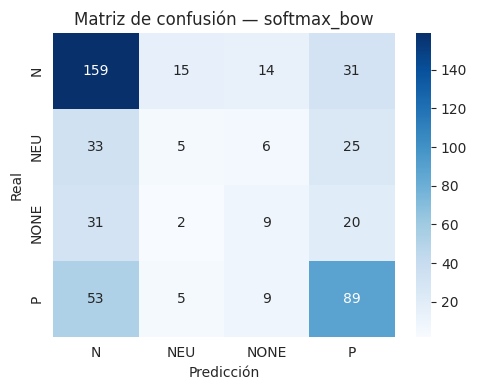

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



============== SOFTMAX_TFIDF — TEST FINAL =============
              precision    recall  f1-score   support

           N       0.57      0.62      0.59       219
         NEU       0.12      0.12      0.12        69
        NONE       0.26      0.24      0.25        62
           P       0.52      0.48      0.50       156

    accuracy                           0.46       506
   macro avg       0.37      0.36      0.36       506
weighted avg       0.45      0.46      0.46       506



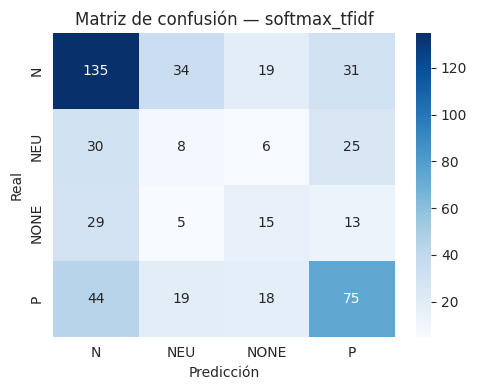


============== LINEARSVC_BOW — TEST FINAL =============
              precision    recall  f1-score   support

           N       0.53      0.87      0.66       219
         NEU       0.00      0.00      0.00        69
        NONE       0.20      0.02      0.03        62
           P       0.60      0.54      0.57       156

    accuracy                           0.55       506
   macro avg       0.33      0.36      0.32       506
weighted avg       0.44      0.55      0.47       506



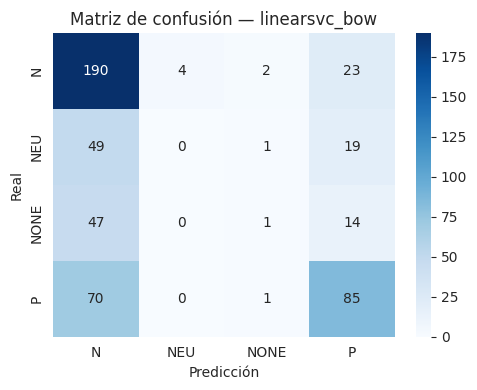


============= LINEARSVC_TFIDF — TEST FINAL ============
              precision    recall  f1-score   support

           N       0.58      0.70      0.63       219
         NEU       0.09      0.06      0.07        69
        NONE       0.23      0.18      0.20        62
           P       0.56      0.53      0.55       156

    accuracy                           0.50       506
   macro avg       0.36      0.37      0.36       506
weighted avg       0.46      0.50      0.48       506



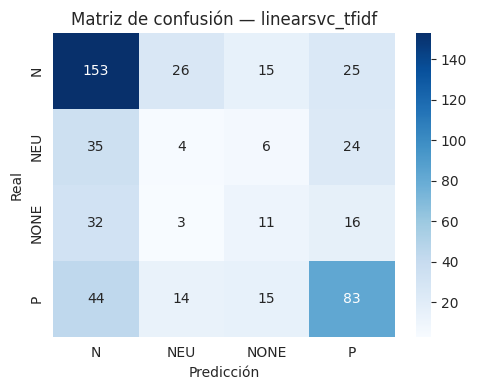

In [ ]:

# ------------------------------------------------------------------ #
#  5. Evaluación final sobre test + reporte por clase                #
# ------------------------------------------------------------------ #
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_results = {}   # guarda predicciones para uso posterior (LIME, SHAP, etc.)

for method, config in validation_schema.items():
    model = config["model"]
    X_tr  = config["data"]["train"]
    y_tr  = np.array(config["target"]["train"])
    X_te  = config["data"]["test"]
    y_te  = config["target"]["test"]

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    test_results[method] = {"y_true": y_te, "y_pred": y_pred}

    print(f"\n{'='*55}")
    print(f" {method.upper()} — TEST FINAL ".center(55, "="))
    print(f"{'='*55}")
    print(classification_report(y_te, y_pred, zero_division=0))

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        confusion_matrix(y_te, y_pred),
        annot=True, fmt='d', cmap='Blues',
        xticklabels=np.unique(y_te),
        yticklabels=np.unique(y_te)
    )
    plt.title(f'Matriz de confusión — {method}')
    plt.ylabel('Real'); plt.xlabel('Predicción')
    plt.tight_layout()
    plt.show()

In [ ]:
final_rows = []
for method, res in test_results.items():
    final_rows.append({
        "modelo":    method,
        "f1_macro":  round(f1_score(res["y_true"], res["y_pred"], average='macro') * 100, 2),
        "f1_weighted": round(f1_score(res["y_true"], res["y_pred"], average='weighted') * 100, 2),
        "accuracy":  round(accuracy_score(res["y_true"], res["y_pred"]) * 100, 2),
        "recall_macro": round(recall_score(res["y_true"], res["y_pred"], average='macro') * 100, 2),
    })

df_final = pd.DataFrame(final_rows).sort_values("f1_macro", ascending=False)
print("\n===== COMPARATIVA FINAL SOBRE TEST =====")
print(df_final.to_string(index=False))


===== COMPARATIVA FINAL SOBRE TEST =====
         modelo  f1_macro  f1_weighted  accuracy  recall_macro
    softmax_bow     37.56        48.46     51.78         37.98
  softmax_tfidf     35.97        45.15     45.06         35.90
linearsvc_tfidf     35.46        45.84     47.63         35.61
  linearsvc_bow     29.81        44.93     53.36         34.28


## 13. Entrenamiento y validación cruzada

En el siguiente bloque:

1. Generamos las particiones con `ShuffleSplit`.
2. Entrenamos el modelo `softmax` en los datos de entrenamiento de cada partición.
3. Predecimos sobre la parte de validación.
4. Calculamos las métricas y las guardamos para luego promediarlas.


In [ ]:
for train_index, test_index in k_fold.split(x_train, y_train):
    data_train = x_train[train_index]
    target_train = y_train[train_index]

    data_test = x_train[test_index]
    target_test = y_train[test_index]

    softmax.fit(data_train, target_train)
    predict = softmax.predict(data_test)
    # Accuracy
    accuracy = accuracy_score(target_test, predict)
    accuracies_scores.append(accuracy)
    # Recall
    recall = recall_score(target_test, predict, average='macro')
    recalls_scores.append(recall)
    # Precision
    precision = precision_score(target_test, predict, average='weighted')
    precisions_scores.append(precision)
    # F1
    f1 = f1_score(target_test, predict, average='weighted')
    f1_scores.append(f1)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

## 14. Resultados promedio en validación

Calculamos el valor promedio de cada métrica a lo largo de las particiones.


In [ ]:
average_recall = round(np.mean(recalls_scores) * 100, 2)
average_precision = round(np.mean(precisions_scores) * 100, 2)
average_f1 = round(np.mean(f1_scores) * 100, 2)
average_accuracy = round(np.mean(accuracies_scores) * 100, 2)

In [ ]:
average_recall

np.float64(80.24)

## 15. Evaluación final sobre el conjunto de prueba

Entrenamos el modelo final y evaluamos sobre el conjunto de prueba para obtener:

- **Reporte de clasificación** por clase.
- **Matriz de confusión**, que muestra cómo se confunden las clases entre sí.

Estas salidas permiten discutir en el taller:
- Qué clases se predicen mejor o peor.
- Cómo influye el desbalance y la representación BOW.
- Posibles mejoras (embeddings, modelos neuronales, ajuste de parámetros, etc.).


In [ ]:
y_predict = []
for features in x_test:
    features = features.reshape(1, -1)
    value = softmax.predict(features)[0]
    y_predict.append(value)

classification = classification_report(y_test, y_predict)
confusion = confusion_matrix(y_predict, y_test)

In [ ]:
output_result = {'F1-score': average_f1, 'Accuracy': average_accuracy, 'Recall': average_recall,
                 'Precision': average_precision, 'Classification Report\n': classification,
                 'Confusion Matrix\n': confusion}

In [ ]:
for item, val in output_result.items():
    print('{0} {1}'.format(item, val))

F1-score 80.21
Accuracy 80.26
Recall 80.24
Precision 80.34
Classification Report
               precision    recall  f1-score   support

           N       0.35      0.69      0.47       219
         NEU       0.46      0.19      0.27       219
        NONE       0.42      0.18      0.25       219
           P       0.39      0.47      0.43       219

    accuracy                           0.38       876
   macro avg       0.41      0.38      0.35       876
weighted avg       0.41      0.38      0.35       876

Confusion Matrix
 [[151  92 109  78]
 [ 15  41  21  12]
 [ 15  14  39  25]
 [ 38  72  50 104]]


## 16. Próximos pasos sugeridos para el taller

Algunas extensiones que se pueden proponer a los participantes:

- Probar distintas configuraciones de `CountVectorizer` (solo unigramas, límite de vocabulario, stopwords, etc.).
- Comparar la Regresión Logística con otros clasificadores (SVM, árboles, redes neuronales sencillas).
- Analizar ejemplos mal clasificados a partir de la matriz de confusión.
- Integrar representaciones basadas en *embeddings* para comparar con la bolsa de palabras.

Con estas actividades, el notebook sirve como guía completa de un pipeline clásico de NLP aplicado a TASS 2018.
